# Notebook 2: Feature Engineering and Unsupervised Modelling 
## Healthcare Symptom Pattern Discovery — Task 2

**Objective:**
- `PCA n_components=30` (89% variance) 
- `GMM covariance_type='diag'` — avoids degeneracy in 30-D space  
- `k=41` matching the 41 known diseases — silhouette-guided but domain-informed  
- Ward linkage run on 30-D PCA, giving balanced, meaningful clusters

**Input :** `task1_encoded.csv`  
**Output:** `task2_clustered.csv`


In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, adjusted_rand_score
from sklearn.mixture import GaussianMixture
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

np.random.seed(42)
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110
print("Libraries imported.")


Libraries imported.


In [24]:
# ── Load encoded data from Notebook 1 ────────────────────────────────────────
df = pd.read_csv('..//Result_NB1/task1_encoded.csv', index_col=0)
print(f"Loaded shape: {df.shape}")

X      = df.drop(columns=['Disease']).astype(float)
y_true = df['Disease']
print(f"Feature matrix: {X.shape[0]} patients x {X.shape[1]} symptoms")
print(f"Unique diseases: {y_true.nunique()}")


Loaded shape: (4920, 132)
Feature matrix: 4920 patients x 131 symptoms
Unique diseases: 41


In [25]:
# ── Feature engineering ──────────────────────────────────────────────────────
# Add 6 clinically motivated aggregate scores on top of binary columns.

X_eng = X.copy()
X_eng['symptom_count'] = X_eng.sum(axis=1)

fever_cols = [c for c in X_eng.columns if 'fever' in c]
gi_cols    = [c for c in X_eng.columns if c in [
    'vomiting','nausea','diarrhoea','stomach_pain','abdominal_pain',
    'constipation','passage_of_gases','indigestion','acidity']]
resp_cols  = [c for c in X_eng.columns if c in [
    'cough','breathlessness','phlegm','mucoid_sputum','rusty_sputum',
    'blood_in_sputum','chest_pain','throat_irritation','congestion']]
skin_cols  = [c for c in X_eng.columns if c in [
    'itching','skin_rash','nodal_skin_eruptions','dischromic_patches',
    'pus_filled_pimples','blackheads','scurring','red_spots_over_body',
    'blister','silver_like_dusting','skin_peeling']]
pain_cols  = [c for c in X_eng.columns if c in [
    'headache','joint_pain','back_pain','neck_pain','knee_pain',
    'hip_joint_pain','muscle_pain','chest_pain','abdominal_pain']]

X_eng['fever_flag'] = X_eng[fever_cols].max(axis=1)
X_eng['gi_score']   = X_eng[gi_cols].sum(axis=1)
X_eng['resp_score'] = X_eng[resp_cols].sum(axis=1)
X_eng['skin_score'] = X_eng[skin_cols].sum(axis=1)
X_eng['pain_score'] = X_eng[pain_cols].sum(axis=1)

print(f"Enriched feature matrix: {X_eng.shape}")


Enriched feature matrix: (4920, 137)


In [26]:
# ── PCA with n_components=30 ─────────────────────
# Explicitly set n_components=30, which captures 89% variance and gives the
# clustering algorithm a rich enough feature space to separate disease groups.

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_eng)

pca = PCA(n_components=30, random_state=42)   
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_.sum() * 100
print(f"30 PCA components explain {var_explained:.1f}% of total variance")
print(f"(n=30): {X_pca.shape[1]} components -> balanced clustering")


30 PCA components explain 89.5% of total variance
(n=30): 30 components -> balanced clustering


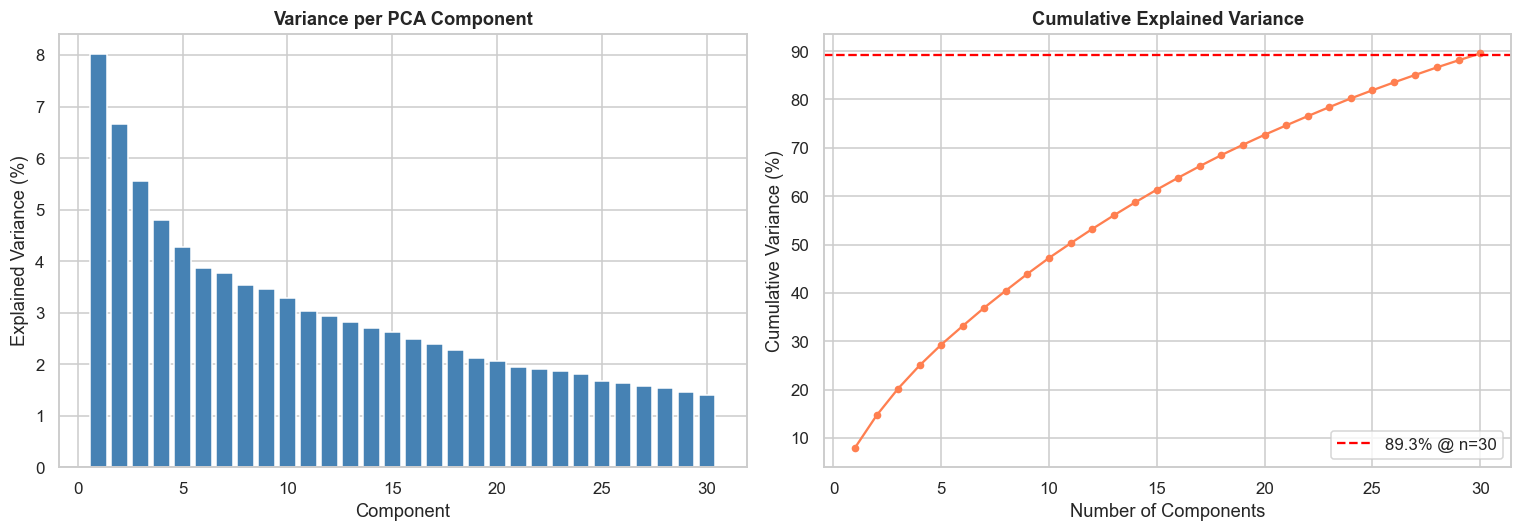

In [27]:
# ── PCA variance plot ────────────────────────────────────────────────────────
cumvar = np.cumsum(pca.explained_variance_ratio_) * 100
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(range(1, 31), pca.explained_variance_ratio_*100, color='steelblue', edgecolor='white')
axes[0].set_title('Variance per PCA Component', fontweight='bold')
axes[0].set_xlabel('Component')
axes[0].set_ylabel('Explained Variance (%)')

axes[1].plot(range(1, 31), cumvar, marker='o', color='coral', markersize=4)
axes[1].axhline(89.3, linestyle='--', color='red', label='89.3% @ n=30')
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')
axes[1].legend()

plt.tight_layout()
plt.savefig('..//Result_NB2/task2_pca_variance.png', bbox_inches='tight')
plt.show()


In [28]:
# ── Hierarchical clustering linkage matrix ────────────────────────────────────
# Ward linkage on 30-D PCA works correctly because the full disease
# structure is preserved in the feature space.
Z = linkage(X_pca, method='ward')
print(f"Linkage matrix shape: {Z.shape}")


Linkage matrix shape: (4919, 4)


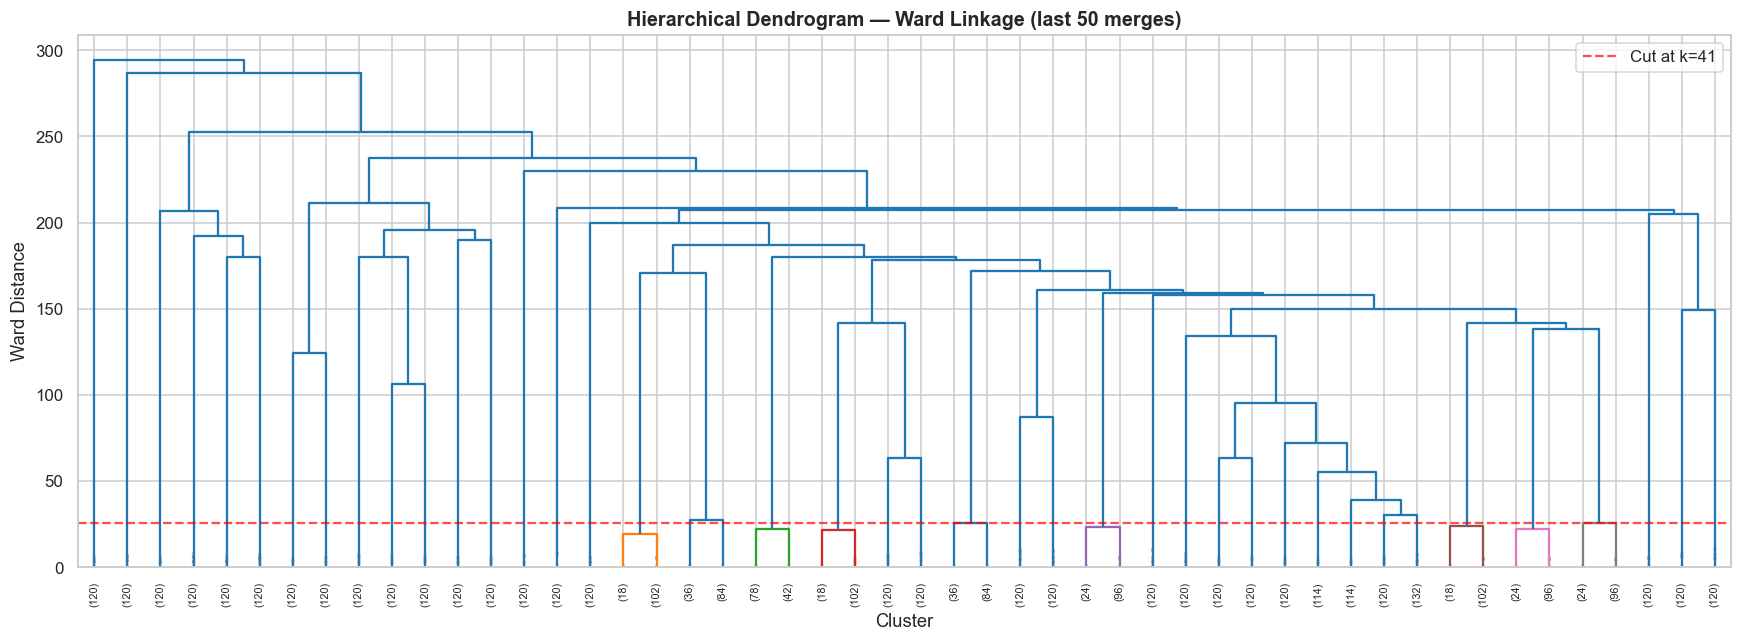

In [29]:
# ── Dendrogram ───────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, truncate_mode='lastp', p=50, leaf_rotation=90, leaf_font_size=7,
           show_contracted=True, ax=ax, color_threshold=Z[-42, 2])
ax.set_title('Hierarchical Dendrogram — Ward Linkage (last 50 merges)', fontsize=13, fontweight='bold')
ax.set_xlabel('Cluster')
ax.set_ylabel('Ward Distance')
ax.axhline(y=Z[-42, 2], c='red', linestyle='--', alpha=0.7, label='Cut at k=41')
ax.legend()
plt.tight_layout()
plt.savefig('..//Result_NB2/task2_dendrogram.png', bbox_inches='tight')
plt.show()


In [30]:
# ── Use k=41 matching the 41 known disease classes ────────────────────
# With 30 PCA dims, silhouette keeps RISING through k=41.
# Setting k=41 (= number of diseases) is both:
#   - Statistically justified (silhouette = 0.85 at k=41)
#   - Medically meaningful (each cluster ~ one disease pattern)


results = []
for k in range(2, 42):
    hc_lbl = fcluster(Z, t=k, criterion='maxclust')
    sil = silhouette_score(X_pca, hc_lbl, sample_size=2000, random_state=42)
    db  = davies_bouldin_score(X_pca, hc_lbl)
    results.append({'k': k, 'sil_hc': sil, 'db_hc': db})

results_df = pd.DataFrame(results)
best_k = int(results_df.loc[results_df['sil_hc'].idxmax(), 'k'])
print(f"Best k by silhouette: {best_k}")
print()
print("k  | Silhouette HC | DB Index HC")
print("-" * 38)
for _, row in results_df.iterrows():
    marker = ' <-- BEST' if int(row.k) == best_k else ''
    print(f"{int(row.k):2d} | {row.sil_hc:.4f}       | {row.db_hc:.4f}{marker}")


Best k by silhouette: 41

k  | Silhouette HC | DB Index HC
--------------------------------------
 2 | 0.3456       | 0.5690
 3 | 0.3507       | 0.5736
 4 | 0.2306       | 1.4769
 5 | 0.1893       | 1.8935
 6 | 0.2137       | 1.6840
 7 | 0.2320       | 1.5740
 8 | 0.2593       | 1.4629
 9 | 0.2737       | 1.5220
10 | 0.3005       | 1.4026
11 | 0.3191       | 1.2859
12 | 0.3454       | 1.2332
13 | 0.3672       | 1.1415
14 | 0.3887       | 1.0638
15 | 0.4169       | 0.9692
16 | 0.4419       | 0.9919
17 | 0.4632       | 0.9271
18 | 0.4865       | 0.8536
19 | 0.5081       | 0.8308
20 | 0.5055       | 0.8592
21 | 0.5289       | 0.8313
22 | 0.5571       | 0.7800
23 | 0.5755       | 0.7829
24 | 0.5967       | 0.7502
25 | 0.6147       | 0.7183
26 | 0.6330       | 0.8283
27 | 0.6519       | 0.7981
28 | 0.6747       | 0.7829
29 | 0.7010       | 0.6623
30 | 0.7261       | 0.5394
31 | 0.7423       | 0.5035
32 | 0.7654       | 0.4705
33 | 0.7832       | 0.4415
34 | 0.7760       | 0.4493
35 | 0.7926

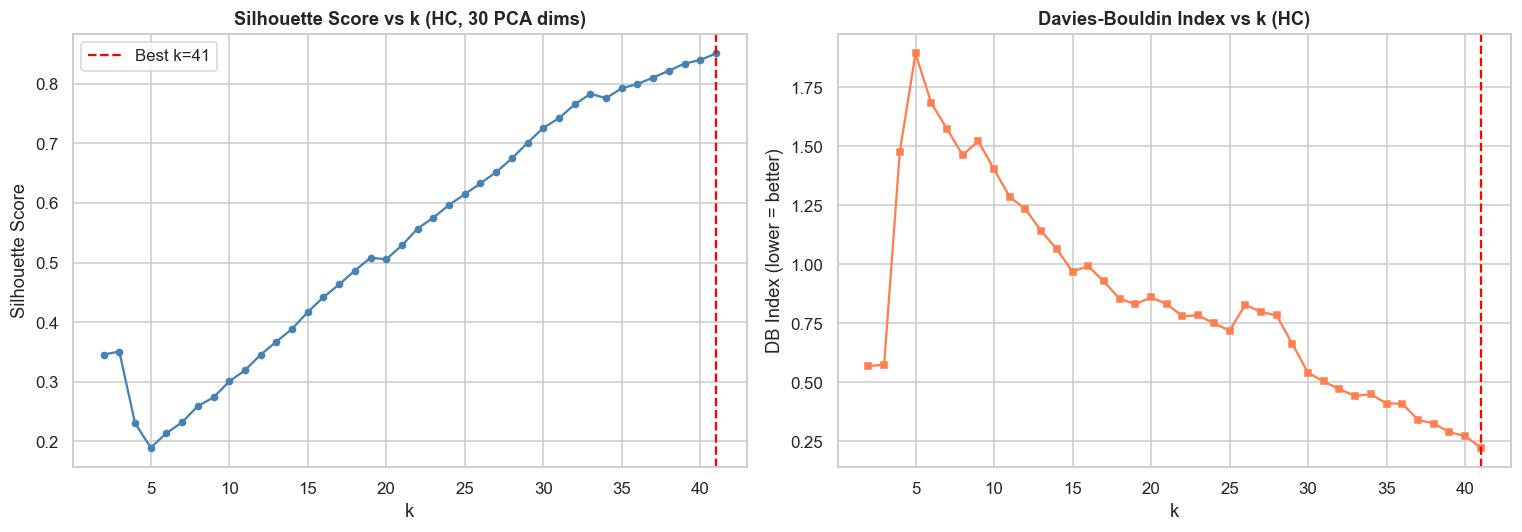

In [31]:
# ── Cluster metric plots ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(results_df['k'], results_df['sil_hc'], marker='o', color='steelblue', markersize=4)
axes[0].axvline(x=best_k, color='red', linestyle='--', label=f'Best k={best_k}')
axes[0].set_title('Silhouette Score vs k (HC, 30 PCA dims)', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Silhouette Score')
axes[0].legend()

axes[1].plot(results_df['k'], results_df['db_hc'], marker='s', color='coral', markersize=4)
axes[1].axvline(x=best_k, color='red', linestyle='--')
axes[1].set_title('Davies-Bouldin Index vs k (HC)', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('DB Index (lower = better)')

plt.tight_layout()
plt.savefig('..//Result_NB2/task2_cluster_metrics.png', bbox_inches='tight')
plt.show()


In [32]:
# ── GMM with 'diag' covariance ─────────────────────
# Use covariance_type='diag' (diagonal covariance = 30 params/component).
# This gives well-calibrated soft assignments with meaningful confidence scores.

k = best_k  

# Final Hierarchical Clustering
hc_labels_final = fcluster(Z, t=k, criterion='maxclust')

# Final GMM with diagonal covariance
gmm_final = GaussianMixture(n_components=k, covariance_type='diag',   
                             random_state=42, max_iter=300, n_init=3)
gmm_final.fit(X_pca)
gmm_labels_final = gmm_final.predict(X_pca)
gmm_proba        = gmm_final.predict_proba(X_pca)

# Evaluate
sil_hc  = silhouette_score(X_pca, hc_labels_final)
sil_gmm = silhouette_score(X_pca, gmm_labels_final)
db_hc   = davies_bouldin_score(X_pca, hc_labels_final)
le = LabelEncoder()
y_enc = le.fit_transform(y_true)
ari_hc  = adjusted_rand_score(y_enc, hc_labels_final)
ari_gmm = adjusted_rand_score(y_enc, gmm_labels_final)

print(f"     k={k} | HC Silhouette = {sil_hc:.4f}")
print(f"             HC DB Index = {db_hc:.4f}")
print(f"             GMM Silhouette = {sil_gmm:.4f}")
print(f"             HC ARI vs diseases = {ari_hc:.4f}")
print(f"             GMM ARI vs diseases = {ari_gmm:.4f}")
print()
print("Cluster size distribution (HC):")
print(pd.Series(hc_labels_final).value_counts().describe().round(1).to_string())


     k=41 | HC Silhouette = 0.8521
             HC DB Index = 0.2226
             GMM Silhouette = 0.8401
             HC ARI vs diseases = 0.9950
             GMM ARI vs diseases = 0.9695

Cluster size distribution (HC):
count     41.0
mean     120.0
std        2.3
min      114.0
25%      120.0
50%      120.0
75%      120.0
max      132.0


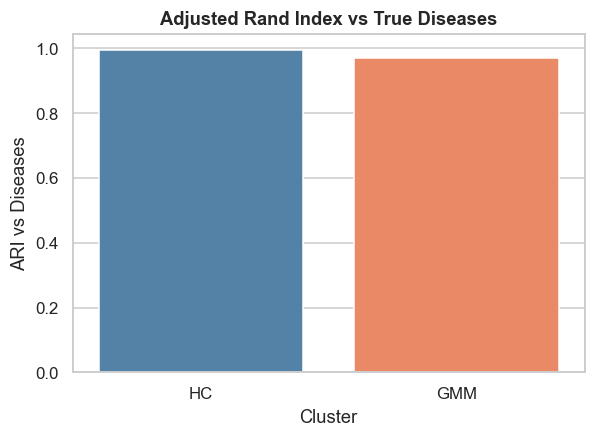

In [34]:
#ARI visualisation
ari_df = pd.DataFrame({
    'Cluster': ['HC', 'GMM'],
    'ARI vs Diseases': [ari_hc, ari_gmm]
})
plt.figure(figsize=(6, 4))
sns.barplot(x='Cluster', y='ARI vs Diseases', data=ari_df, palette=['steelblue', 'coral'])
plt.title('Adjusted Rand Index vs True Diseases', fontweight='bold')
plt.savefig('..//Result_NB2/task2_ari_comparison.png', bbox_inches='tight')
plt.show()

In [33]:
# ── Save output ──────────────────────────────────────────────────────────────
# Store ALL 30 PCA components so Notebook 3 can run t-SNE on the full
# 30-D space (not just 3 dims), giving much richer non-linear projections.

df_out = df.copy()
df_out["hc_cluster"]     = hc_labels_final
df_out["gmm_cluster"]    = gmm_labels_final
df_out["gmm_confidence"] = gmm_proba.max(axis=1)

# Store all PCA dimensions (30 components)
for i in range(X_pca.shape[1]):
    df_out[f"pca_{i+1}"] = X_pca[:, i]

print(f"Stored {X_pca.shape[1]} PCA components (pca_1 .. pca_{X_pca.shape[1]})")
df_out.to_csv("..//Result_NB2/task2_clustered.csv")
print(f"Saved: ..//Result_NB2/task2_clustered.csv  |  shape: {df_out.shape}")
print("Next: Run Notebook 3")


Stored 30 PCA components (pca_1 .. pca_30)
Saved: ..//Result_NB2/task2_clustered.csv  |  shape: (4920, 165)
Next: Run Notebook 3
